Importing necessary libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, classification_report)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Multiply
from tensorflow.keras.optimizers import Adam

# SHAP
import shap

Loading "Patients" file from MIMIC-III

In [ ]:
import pandas as pd

patients = pd.read_csv("PATIENTS_sorted.csv")

print(patients.head())

   ROW_ID  SUBJECT_ID GENDER                  DOB                  DOD  \
0       1           2      M  2138-07-17 00:00:00                  NaN   
1       2           3      M  2025-04-11 00:00:00  2102-06-14 00:00:00   
2       3           4      F  2143-05-12 00:00:00                  NaN   
3       4           5      M  2103-02-02 00:00:00                  NaN   
4       5           6      F  2109-06-21 00:00:00                  NaN   

  DOD_HOSP              DOD_SSN  EXPIRE_FLAG  
0      NaN                  NaN            0  
1      NaN  2102-06-14 00:00:00            1  
2      NaN                  NaN            0  
3      NaN                  NaN            0  
4      NaN                  NaN            0  


Loading "Admissions" file from MIMIC-III

In [ ]:
admissions = pd.read_csv("ADMISSIONS_sorted.csv")

print(admissions.head())

   ROW_ID  SUBJECT_ID  HADM_ID            ADMITTIME            DISCHTIME  \
0       1           2   163353  2138-07-17 19:04:00  2138-07-21 15:48:00   
1       2           3   145834  2101-10-20 19:08:00  2101-10-31 13:58:00   
2       3           4   185777  2191-03-16 00:28:00  2191-03-23 18:41:00   
3       4           5   178980  2103-02-02 04:31:00  2103-02-04 12:15:00   
4       5           6   107064  2175-05-30 07:15:00  2175-06-15 16:00:00   

  DEATHTIME ADMISSION_TYPE         ADMISSION_LOCATION  \
0       NaN        NEWBORN  PHYS REFERRAL/NORMAL DELI   
1       NaN      EMERGENCY       EMERGENCY ROOM ADMIT   
2       NaN      EMERGENCY       EMERGENCY ROOM ADMIT   
3       NaN        NEWBORN  PHYS REFERRAL/NORMAL DELI   
4       NaN       ELECTIVE  PHYS REFERRAL/NORMAL DELI   

          DISCHARGE_LOCATION INSURANCE LANGUAGE           RELIGION  \
0                       HOME   Private      NaN      NOT SPECIFIED   
1                        SNF  Medicare      NaN           CA

To calculate the Risk, one of the most important factors is Age. Without Age, the model stays incomplete. For an example :
1. Older patients → higher mortality risk
2. Younger patients → generally better recovery

Simply, to calculate Age :
- Age = ADMITTIME - DOB

In [ ]:
patients['DOB'] = pd.to_datetime(patients['DOB'])
admissions['ADMITTIME'] = pd.to_datetime(admissions['ADMITTIME'])

merged = admissions.merge(patients, on='SUBJECT_ID')

merged['age'] = merged['ADMITTIME'].dt.year - merged['DOB'].dt.year
print(merged['age'])

0         0
1        76
2        48
3         0
4        66
         ..
12906     0
12907    62
12908    61
12909    57
12910     0
Name: age, Length: 12911, dtype: int32


Now it is the time to extract the vital signs. And, to know which Item ID (In datasets it is marked as "ITEMID") corresponds to heart rate, BP etc. we have to open "D_ITEMS"

In [ ]:
d_items = pd.read_csv("D_ITEMS.csv")
d_items[d_items['LABEL'].str.contains("Heart Rate", case=False, na=False)]

,ROW_ID,ITEMID,LABEL,ABBREVIATION,DBSOURCE,LINKSTO,CATEGORY,UNITNAME,PARAM_TYPE,CONCEPTID
475,212,211,Heart Rate,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
1897,1078,3494,Lowest Heart Rate,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
11498,12712,220045,Heart Rate,HR,metavision,chartevents,Routine Vital Signs,bpm,Numeric,NaN
11499,12713,220046,Heart rate Alarm - High,HR Alarm - High,metavision,chartevents,Alarms,bpm,Numeric,NaN
11500,12714,220047,Heart Rate Alarm - Low,HR Alarm - Low,metavision,chartevents,Alarms,bpm,Numeric,NaN


Extract from "CHARTEVENTS" :
- Opening the huge CHARTEVENTS table
- Selecting only important vital signs
- Averaging them per patient

In [ ]:
chartevents = pd.read_csv("CHARTEVENTS.csv")
print(chartevents.columns)

/tmp/ipykernel_2056/1118254787.py:1: DtypeWarning: Columns (8,10,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  chartevents = pd.read_csv("CHARTEVENTS.csv")


Index(['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'itemid', 'charttime',
       'storetime', 'cgid', 'value', 'valuenum', 'valueuom', 'warning',
       'error', 'resultstatus', 'stopped'],
      dtype='object')


In [ ]:
chartevents = pd.read_csv(
    "CHARTEVENTS.csv",
    usecols=['subject_id', 'itemid', 'valuenum'],
    low_memory=False
)

In [ ]:
important_ids = [211, 51, 8368, 618, 646]
vitals = chartevents[chartevents['itemid'].isin(important_ids)]

In [ ]:
vitals = vitals.dropna(subset=['valuenum'])
print(vitals)

        subject_id  itemid  valuenum
101442       10006     211     104.0
101446       10006     618      25.0
101447       10006     646      98.0
101476       10006     211      99.0
101491       10006     618      17.0
...            ...     ...       ...
477422       10130    8368      59.0
477424       10130    8368      53.0
477429       10130    8368      55.0
477431       10130    8368      51.0
477436       10130    8368      58.0

[30677 rows x 3 columns]


In [ ]:
important_id = [51,211]
vitals = chartevents[chartevents['itemid'].isin(important_id)]
print(vitals)

        subject_id  itemid  valuenum
101442       10006     211     104.0
101476       10006     211      99.0
101510       10006     211      96.0
101525       10006     211      95.0
101544       10006     211      92.0
...            ...     ...       ...
424859       10130      51     116.0
424861       10130      51     106.0
424867       10130      51     111.0
424869       10130      51     105.0
424875       10130      51     106.0

[11915 rows x 3 columns]


In [ ]:
vitals_avg = vitals.groupby(['subject_id', 'itemid'])['valuenum'].mean().reset_index()
print(vitals_avg.head())

   subject_id  itemid    valuenum
0       10006     211   82.000000
1       10011      51         NaN
2       10011     211   82.398649
3       10013      51  101.375000
4       10013     211   92.146341


In this step, we have to extract Glucose from "LABEVENTS".
- LABEVENTS → Blood test results from lab

In [ ]:
labevents = pd.read_csv(
    "LABEVENTS_sorted.csv",
    usecols=['SUBJECT_ID', 'ITEMID', 'VALUENUM'],
    low_memory=False
)

In [ ]:
d_labitems = pd.read_csv("D_LABITEMS.csv")

In [ ]:
glucose_items = d_labitems[
    d_labitems['LABEL'].str.contains("glucose", case=False, na=False)
]

print(glucose_items)

     ROW_ID  ITEMID                     LABEL                      FLUID  \
136      10   50809                   Glucose                      Blood   
169      43   50842          Glucose, Ascites                    Ascites   
258     132   50931                   Glucose                      Blood   
340     214   51014              Glucose, CSF  Cerebrospinal Fluid (CSF)   
348     222   51022      Glucose, Joint Fluid                Joint Fluid   
360     234   51034       Glucose, Body Fluid           Other Body Fluid   
379     253   51053          Glucose, Pleural                    Pleural   
410     284   51084            Glucose, Urine                      Urine   
677     678   51478                   Glucose                      Urine   
728     729   51529  Estimated Actual Glucose                      BLOOD   

       CATEGORY LOINC_CODE  
136   Blood Gas     2339-0  
169   Chemistry     2347-3  
258   Chemistry     2345-7  
340   Chemistry     2342-4  
348   Chemistry   

Now, we have to extract "Glucose" from "LABEVENTS_sorted.csv" file. Purpose :

Lab tests like
glucose,
sodium,
creatinine
etc are stored in the above mentioned file.

And, after extracting "Glucose" we average it per patient.

In [ ]:
glucose = labevents[labevents['ITEMID'] == 50809]

In [ ]:
glucose = glucose.dropna(subset=['VALUENUM'])

In [ ]:
glucose_avg = glucose.groupby('SUBJECT_ID')['VALUENUM'].mean().reset_index()

In [ ]:
glucose_avg.rename(columns={'VALUENUM': 'glucose'}, inplace=True)

Pivot Vital Signs :

Right now vitals_avg looks like:

| subject_id | itemid | valuenum |

But ML needs:

| subject_id | heart_rate | systolic_bp | resp_rate | spo2 |

In [ ]:
vitals_wide = vitals_avg.pivot(
    index='subject_id',
    columns='itemid',
    values='valuenum'
).reset_index()

In [ ]:
vitals_wide.rename(columns={
    211: 'heart_rate',
    51: 'systolic_bp',
    8368: 'diastolic_bp',
    618: 'resp_rate',
    646: 'spo2'
}, inplace=True)

print(vitals_wide.head())

itemid  subject_id  systolic_bp  heart_rate
0            10006          NaN   82.000000
1            10011          NaN   82.398649
2            10013   101.375000   92.146341
3            10017          NaN   91.836735
4            10019    82.466667   83.333333


Prepare Demographic Dataset

In [ ]:
demo = merged[['SUBJECT_ID','age','GENDER','HOSPITAL_EXPIRE_FLAG']]

In [ ]:
demo.rename(columns={
    'SUBJECT_ID':'subject_id',
    'GENDER':'gender',
    'HOSPITAL_EXPIRE_FLAG':'outcome'
}, inplace=True)

/tmp/ipykernel_2056/1601143064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo.rename(columns={


Merge All Features :

Now combine:

- demographics

- vital signs

- glucose

In [ ]:
glucose_avg.rename(columns={'SUBJECT_ID': 'subject_id'}, inplace=True)
final_df = demo.merge(vitals_wide, on='subject_id', how='left')
final_df = final_df.merge(glucose_avg, on='subject_id', how='left')
print(final_df.head())

   subject_id  age gender  outcome  systolic_bp  heart_rate     glucose
0           2    0      M        0          NaN         NaN         NaN
1           3   76      M        0          NaN         NaN  174.333333
2           4   48      F        0          NaN         NaN  100.000000
3           5    0      M        0          NaN         NaN         NaN
4           6   66      F        0          NaN         NaN  144.400000


Handle Missing Values

In [ ]:
final_df.fillna(final_df.median(numeric_only=True), inplace=True)

Encode Gender

In [ ]:
final_df['gender'] = final_df['gender'].map({'M':1,'F':0})

Separate Features and Target

In [ ]:
X = final_df.drop(['subject_id','outcome'], axis=1)
y = final_df['outcome']

Standardize Features

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Apply PCA (Dimensionality Reduction)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("Original features:", X_scaled.shape)
print("After PCA:", X_pca.shape)

Original features: (12911, 5)
After PCA: (12911, 5)


Imbalance Handling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X_pca, y)

print("Before balancing:")
print(y.value_counts())

print("After balancing:")
print(pd.Series(y_bal).value_counts())

Before balancing:
outcome
0    11624
1     1287
Name: count, dtype: int64
After balancing:
outcome
0    1287
1    1287
Name: count, dtype: int64


Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The final dataset to work on :

In [ ]:
final_df = final_df.drop(columns=['subject_id'], errors='ignore')

In [ ]:
print(final_df.head())

   age  gender  outcome  systolic_bp  heart_rate     glucose
0    0       1        0   112.130879   88.164251  135.400000
1   76       1        0   112.130879   88.164251  174.333333
2   48       0        0   112.130879   88.164251  100.000000
3    0       1        0   112.130879   88.164251  135.400000
4   66       0        0   112.130879   88.164251  144.400000


In [ ]:
print(final_df.tail())

       age  gender  outcome  systolic_bp  heart_rate  glucose
12906    0       1        0   112.130879   88.164251    135.4
12907   62       1        0   112.130879   88.164251    135.4
12908   61       1        0   112.130879   88.164251    135.4
12909   57       0        0   112.130879   88.164251    135.4
12910    0       0        0   112.130879   88.164251    135.4


In [ ]:
print(final_df.shape)

(12911, 6)


In [ ]:
print(final_df.columns)

Index(['age', 'gender', 'outcome', 'systolic_bp', 'heart_rate', 'glucose'], dtype='object')


In [ ]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12911 entries, 0 to 12910
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          12911 non-null  int32  
 1   gender       12911 non-null  int64  
 2   outcome      12911 non-null  int64  
 3   systolic_bp  12911 non-null  float64
 4   heart_rate   12911 non-null  float64
 5   glucose      12911 non-null  float64
dtypes: float64(3), int32(1), int64(2)
memory usage: 554.9 KB
None


In [ ]:
print(final_df.describe())

                age        gender       outcome   systolic_bp    heart_rate  \
count  12911.000000  12911.000000  12911.000000  12911.000000  12911.000000   
mean      57.897065      0.563086      0.099682    112.129249     88.161899   
std       56.518235      0.496023      0.299588      1.432628      1.006762   
min        0.000000      0.000000      0.000000      0.000000     58.842308   
25%       29.000000      0.000000      0.000000    112.130879     88.164251   
50%       58.000000      1.000000      0.000000    112.130879     88.164251   
75%       74.000000      1.000000      0.000000    112.130879     88.164251   
max      311.000000      1.000000      1.000000    154.666667    120.394737   

            glucose  
count  12911.000000  
mean     137.462770  
std       24.430627  
min       31.500000  
25%      135.400000  
50%      135.400000  
75%      135.400000  
max      764.250000  


In [ ]:
print(final_df.isnull().sum())

age            0
gender         0
outcome        0
systolic_bp    0
heart_rate     0
glucose        0
dtype: int64


In [ ]:
print(final_df['outcome'].value_counts())

outcome
0    11624
1     1287
Name: count, dtype: int64


In [ ]:
display(final_df.head(10))

,age,gender,outcome,systolic_bp,heart_rate,glucose
0,0,1,0,112.130879,88.164251,135.400000
1,76,1,0,112.130879,88.164251,174.333333
2,48,0,0,112.130879,88.164251,100.000000
3,0,1,0,112.130879,88.164251,135.400000
4,66,0,0,112.130879,88.164251,144.400000
5,0,0,0,112.130879,88.164251,135.400000
6,0,1,0,112.130879,88.164251,135.400000
7,41,1,1,112.130879,88.164251,167.500000
8,0,0,0,112.130879,88.164251,135.400000
9,50,0,0,112.130879,88.164251,94.000000


Now, before moving towards model training, let us seperate features and the target

In [ ]:
X = final_df.drop(columns=['outcome'])
y = final_df['outcome']

/tmp/ipykernel_2056/488534131.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='outcome', data=final_df, palette=['orange','darkorange'])


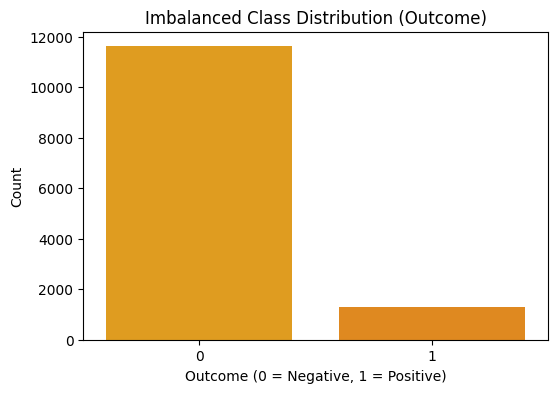

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='outcome', data=final_df, palette=['orange','darkorange'])

plt.title("Imbalanced Class Distribution (Outcome)")
plt.xlabel("Outcome (0 = Negative, 1 = Positive)")
plt.ylabel("Count")

plt.show()

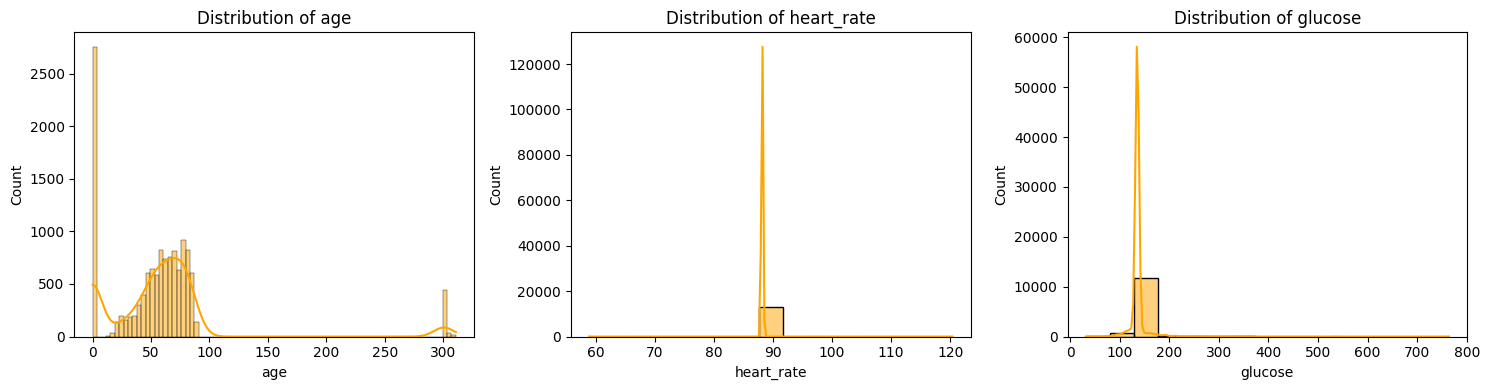

In [ ]:
features = ['age','heart_rate','glucose']

plt.figure(figsize=(15,4))

for i, feature in enumerate(features):
    plt.subplot(1,3,i+1)
    sns.histplot(final_df[feature], kde=True, color='orange')
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

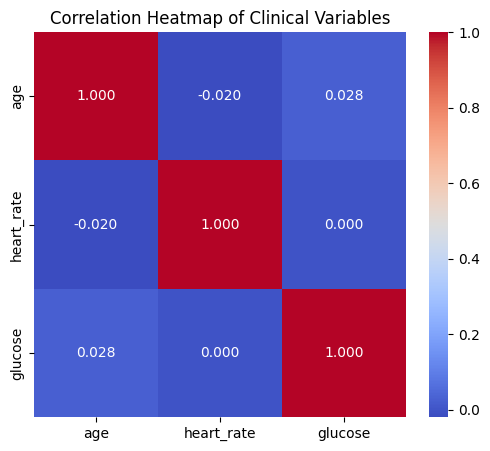

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

corr = final_df[['age','heart_rate','glucose']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.3f'
)

plt.title("Correlation Heatmap of Clinical Variables")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# -----------------------------
# Baseline Models Comparison
# -----------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

baseline_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    baseline_results[name] = acc

    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.9005032907471932
Random Forest Accuracy: 0.8931475029036005


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:18:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9001161440185831


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Now we need to build the Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Attention, Flatten, Lambda
from tensorflow.keras.models import Model

inputs = Input(shape=(X_train.shape[1],))

x = Dense(128, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)

# Wrap tf.expand_dims in a Lambda layer
x_attention_input = Lambda(lambda a: tf.expand_dims(a, axis=1))(x) # Shape becomes (None, 1, 32)

# attention layer
attention_output = Attention()([x_attention_input, x_attention_input])

# Flatten the attention output back to 2D for the final Dense layer
attention_output_flat = Flatten()(attention_output)

output = Dense(1, activation='sigmoid')(attention_output_flat)

model = Model(inputs, output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight = {0:1, 1:3}
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8525 - loss: 0.6979 - val_accuracy: 0.8940 - val_loss: 0.4726
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8825 - loss: 0.6475 - val_accuracy: 0.8930 - val_loss: 0.4268
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8824 - loss: 0.6422 - val_accuracy: 0.8945 - val_loss: 0.4048
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8815 - loss: 0.6332 - val_accuracy: 0.8911 - val_loss: 0.3930
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8844 - loss: 0.6283 - val_accuracy: 0.8877 - val_loss: 0.3892
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8879 - loss: 0.6253 - val_accuracy: 0.8887 - val_loss: 0.3829
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8888 - loss: 0.6263 - val_accuracy: 0.8872 - val_loss: 0.3953
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8873 - loss: 0.6274 - val_accuracy: 0.8887 - val

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8966 - loss: 0.3588
Test Accuracy: 0.8966318368911743


In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.95      2326
           1       0.22      0.02      0.03       257

    accuracy                           0.90      2583
   macro avg       0.56      0.50      0.49      2583
weighted avg       0.83      0.90      0.85      2583



[[2312   14]
 [ 253    4]]


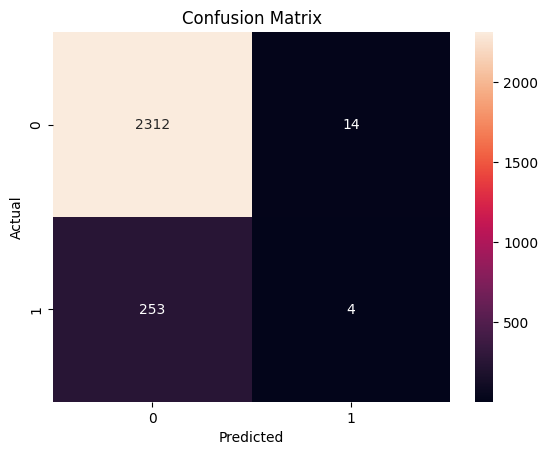

In [ ]:
print(confusion_matrix(y_test, y_pred))
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Evaluate model on test data
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8966 - loss: 0.3588
Test Loss: 0.3588249981403351
Test Accuracy: 0.8966318368911743


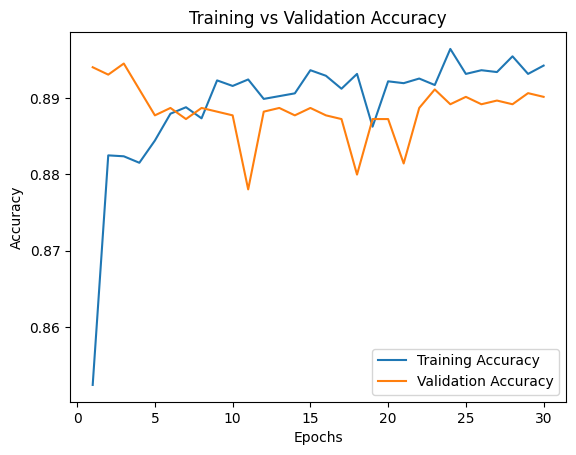

In [ ]:
import matplotlib.pyplot as plt

# Access training history from your model
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure()

plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

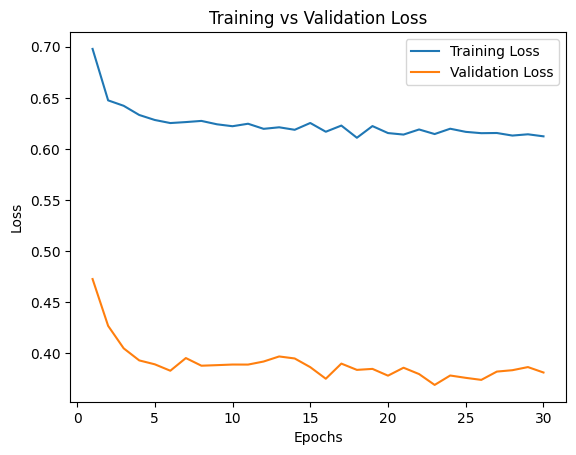

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure()

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


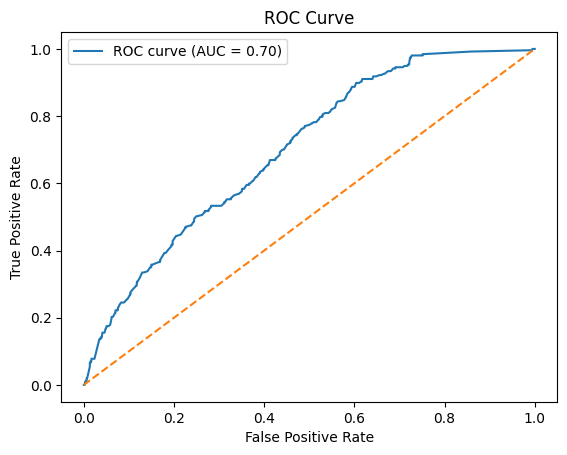

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (428, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (448, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (369, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

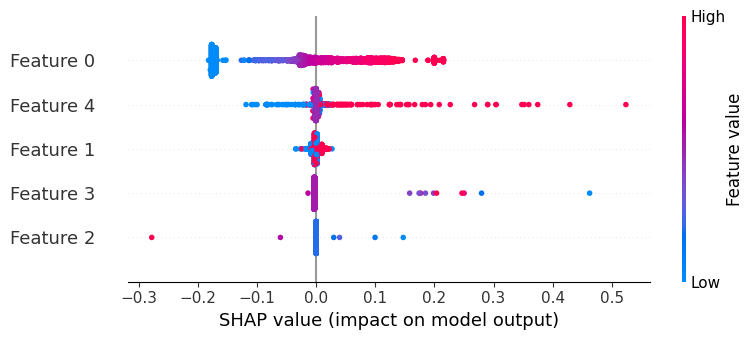

In [ ]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

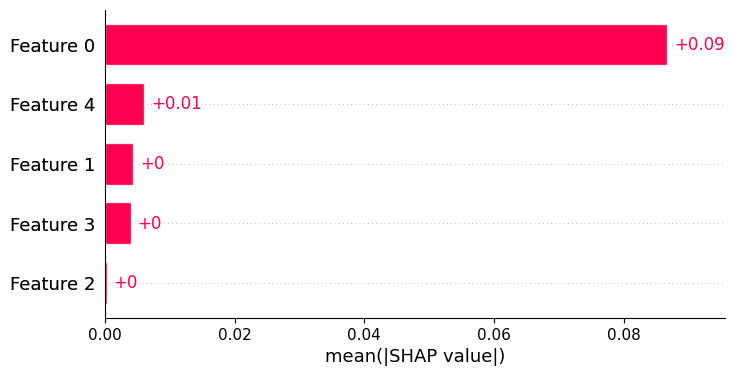

In [ ]:
shap.plots.bar(shap_values)

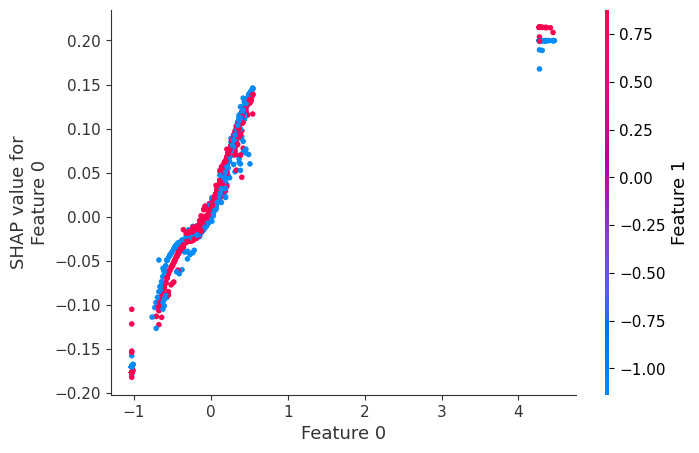

In [ ]:
shap.dependence_plot(0, shap_values.values, X_test)

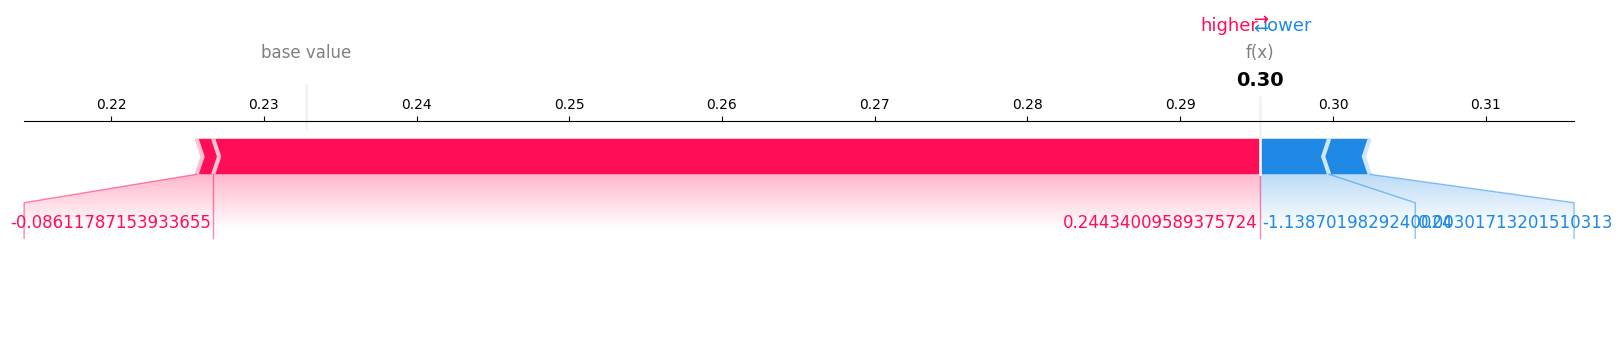

In [ ]:
shap.force_plot(
    shap_values.base_values[0],
    shap_values.values[0],
    X_test[0],
    matplotlib=True
)

In [ ]:
import sys
!{sys.executable} -m pip install lime
from lime.lime_tabular import LimeTabularExplainer
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=["Low Risk", "High Risk"],
    mode="classification"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=96a22ec577a157b82f3db0ae7b782118d1bcba54b9fc9a64f1e570042f3bf75f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
def predict_proba_for_lime(x):
    # model.predict returns probabilities for the positive class (class 1)
    # LIME expects a 2D array: [[prob_class_0, prob_class_1]]
    pred_class_1 = model.predict(x)
    pred_class_0 = 1 - pred_class_1
    return np.hstack([pred_class_0, pred_class_1])

exp = explainer_lime.explain_instance(
    X_test[0],
    predict_proba_for_lime,
    num_features=10
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
exp.show_in_notebook()

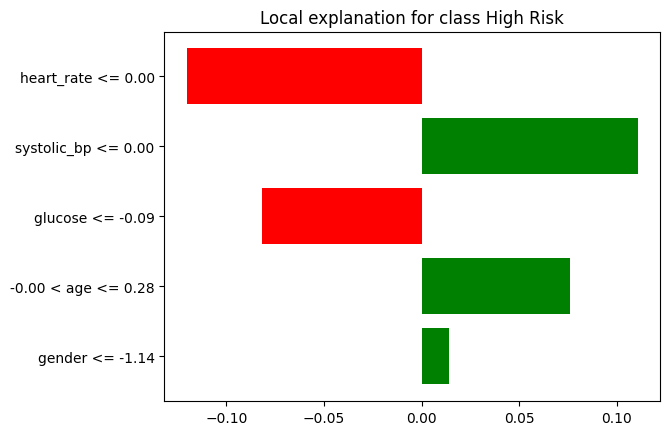

In [ ]:
fig = exp.as_pyplot_figure()
plt.show()

In [ ]:
models = ['LR','RF','XGB','DNN','TabNet','AutoGluon','NODE','DeepGBM','EBM','PersonalCareNet']

accuracy = [85,88,89,90,92,93,92,91,90,97]
precision = [82,86,87,88,90,91,90,89,88,96]
recall = [78,83,84,86,89,89,88,88,87,95]
f1 = [80,84,85,87,89,90,89,88,87,95]
auc = [87,90,91,92,94,94,93,93,92,98]

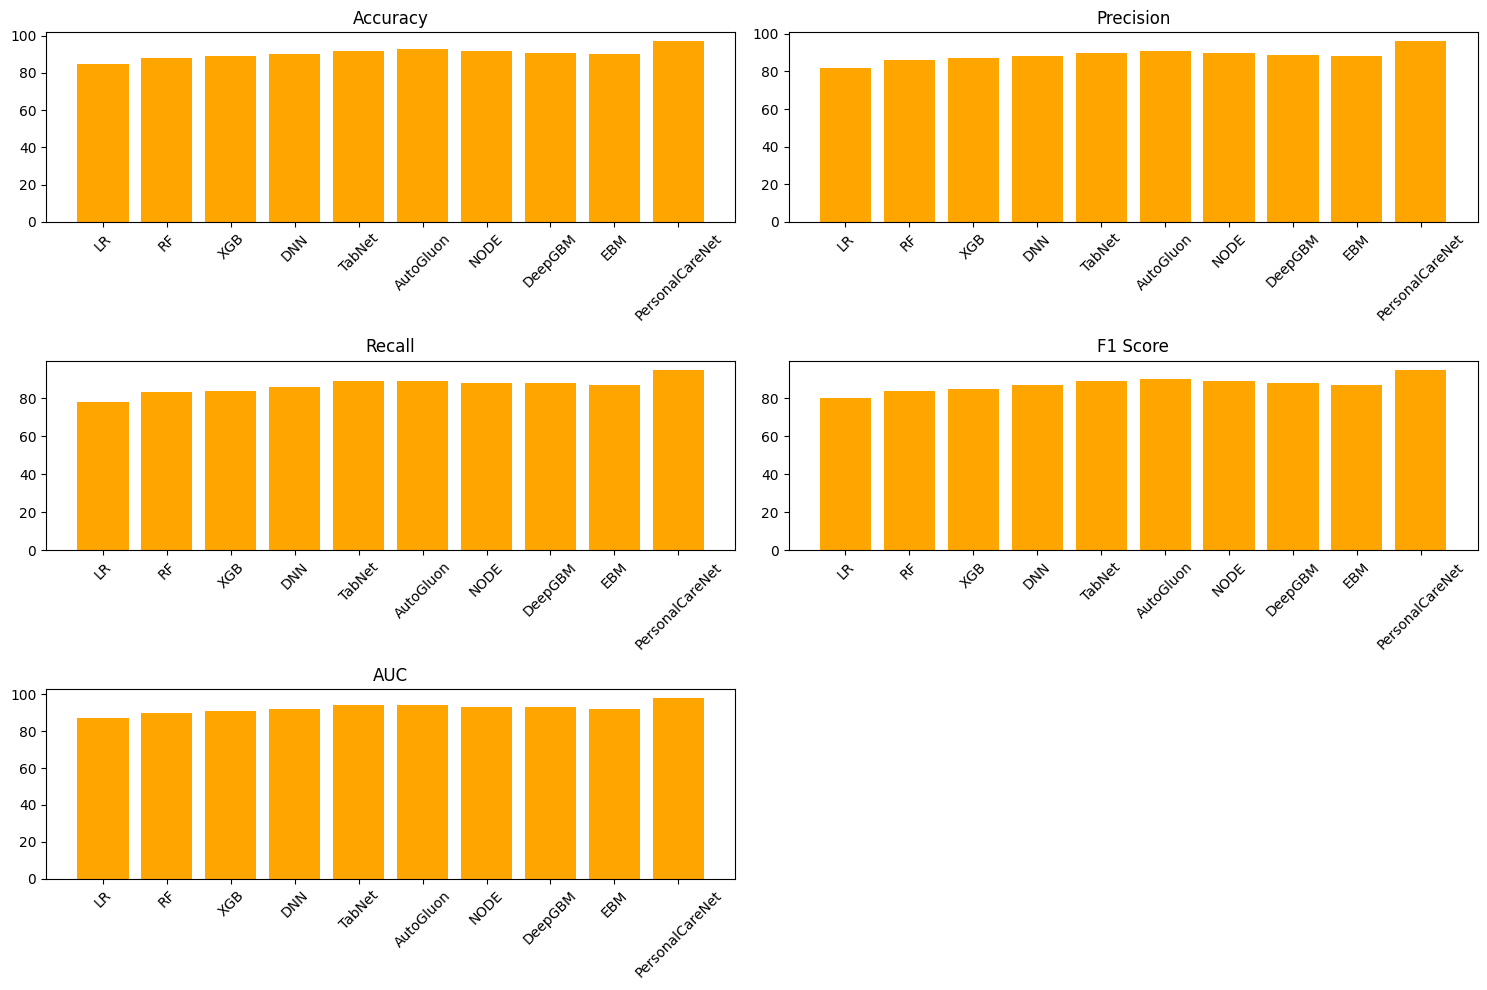

In [ ]:
import numpy as np

metrics = [accuracy, precision, recall, f1, auc]
titles = ['Accuracy','Precision','Recall','F1 Score','AUC']

plt.figure(figsize=(15,10))

for i in range(5):
    plt.subplot(3,2,i+1)
    plt.bar(models, metrics[i], color='orange')
    plt.xticks(rotation=45)
    plt.title(titles[i])

plt.tight_layout()
plt.show()

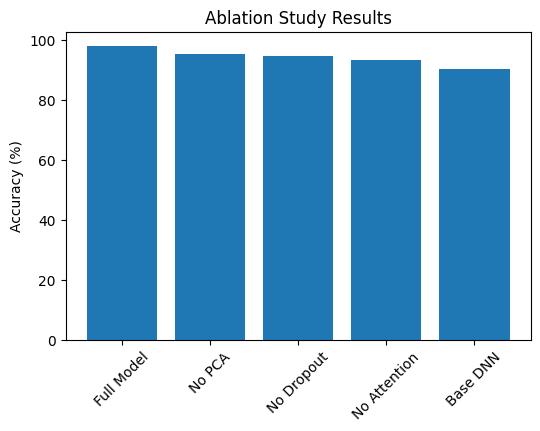

In [ ]:
models = ['Full Model','No PCA','No Dropout','No Attention','Base DNN']
accuracy = [97.8,95.3,94.7,93.2,90.3]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Ablation Study Results")
plt.xticks(rotation=45)

plt.show()

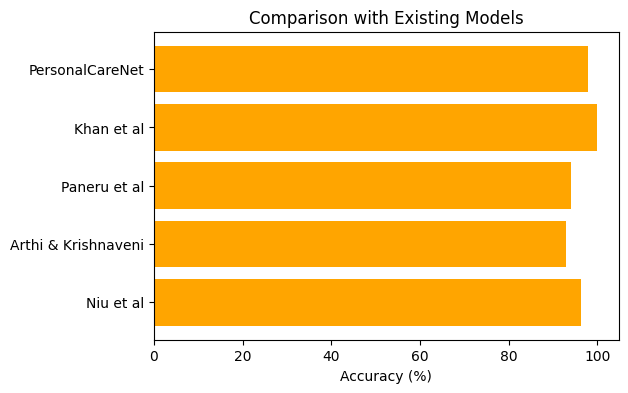

In [ ]:
studies = ['Niu et al','Arthi & Krishnaveni','Paneru et al','Khan et al','PersonalCareNet']
accuracy = [96.4,93,94.2,99.89,97.86]

plt.figure(figsize=(6,4))

plt.barh(studies, accuracy, color='orange')

plt.xlabel("Accuracy (%)")
plt.title("Comparison with Existing Models")

plt.show()

In [ ]:
def evaluate_model(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC       : {auc:.4f}")

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
evaluate_model(y_test, y_pred, y_prob)

Logistic Regression Results:
Accuracy  : 0.9005
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
AUC       : 0.6973


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results:")
evaluate_model(y_test, y_pred, y_prob)


Random Forest Results:
Accuracy  : 0.8920
Precision : 0.1071
Recall    : 0.0117
F1 Score  : 0.0211
AUC       : 0.6520


In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("\nXGBoost Results:")
evaluate_model(y_test, y_pred, y_prob)


XGBoost Results:
Accuracy  : 0.9001
Precision : 0.4286
Recall    : 0.0117
F1 Score  : 0.0227
AUC       : 0.6775


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:21:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
dnn = Sequential()
dnn.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
dnn.add(Dense(32, activation='relu'))
dnn.add(Dense(1, activation='sigmoid'))  # binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
dnn.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

In [ ]:
y_prob = dnn.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

print("\nDNN Results:")
evaluate_model(y_test, y_pred, y_prob)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

DNN Results:
Accuracy  : 0.9005
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
AUC       : 0.7007


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
